# 02 — Rolling VaR Backtest

**Lesson:** How to evaluate a VaR model honestly using out-of-sample testing, and what breach rates tell us about calibration.

This notebook answers: *did the model actually work over time, or did it look good on paper but fail when it mattered?*

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"    # need 504-day warm-up for later notebooks
END_DATE = None               # None = today
WINDOW = 252
CONFIDENCE = 0.95

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.rolling import rolling_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

---

## Part A: The rolling VaR series

For each day after the warm-up window, we compute VaR using only the preceding returns. The current day's return is excluded — no look-ahead bias.

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
returns = prepare_returns(prices)

result = rolling_var(returns, window=WINDOW, confidence=CONFIDENCE)

print(f"\n{len(result)} rolling estimates ({result.index[0].date()} → {result.index[-1].date()})")
print(f"Warm-up: {WINDOW} days used for first estimate")

Prepared 2143 daily returns (2018-01-03 to 2026-07-15) from 2144 price observations.



1891 rolling estimates (2019-01-04 → 2026-07-15)
Warm-up: 252 days used for first estimate


### First 10 rows

In [4]:
display(result.head(10).style.format({
    "VaR": "{:.4%}",
    "NextReturn": "{:.4%}",
}))

,VaR,NextReturn,Breach
Date,,,
2019-01-04 00:00:00,2.1436%,3.3496%,False
2019-01-07 00:00:00,2.1436%,0.7884%,False
2019-01-08 00:00:00,2.1436%,0.9395%,False
2019-01-09 00:00:00,2.1436%,0.4674%,False
2019-01-10 00:00:00,2.1436%,0.3528%,False
2019-01-11 00:00:00,2.1436%,0.0386%,False
2019-01-14 00:00:00,2.1436%,-0.6101%,False
2019-01-15 00:00:00,2.1436%,1.1461%,False
2019-01-16 00:00:00,2.1436%,0.2420%,False


### Last 10 rows

In [5]:
display(result.tail(10).style.format({
    "VaR": "{:.4%}",
    "NextReturn": "{:.4%}",
}))

,VaR,NextReturn,Breach
Date,,,
2026-07-01 00:00:00,1.4126%,-0.1353%,False
2026-07-02 00:00:00,1.4126%,-0.1314%,False
2026-07-06 00:00:00,1.4126%,0.8727%,False
2026-07-07 00:00:00,1.4126%,-0.4752%,False
2026-07-08 00:00:00,1.4126%,-0.3089%,False
2026-07-09 00:00:00,1.4126%,0.8465%,False
2026-07-10 00:00:00,1.4126%,0.4310%,False
2026-07-13 00:00:00,1.4126%,-0.7656%,False
2026-07-14 00:00:00,1.4126%,0.3551%,False


### The rolling VaR over time

VaR adapts as the window slides forward — rising during volatile periods, falling during calm ones.

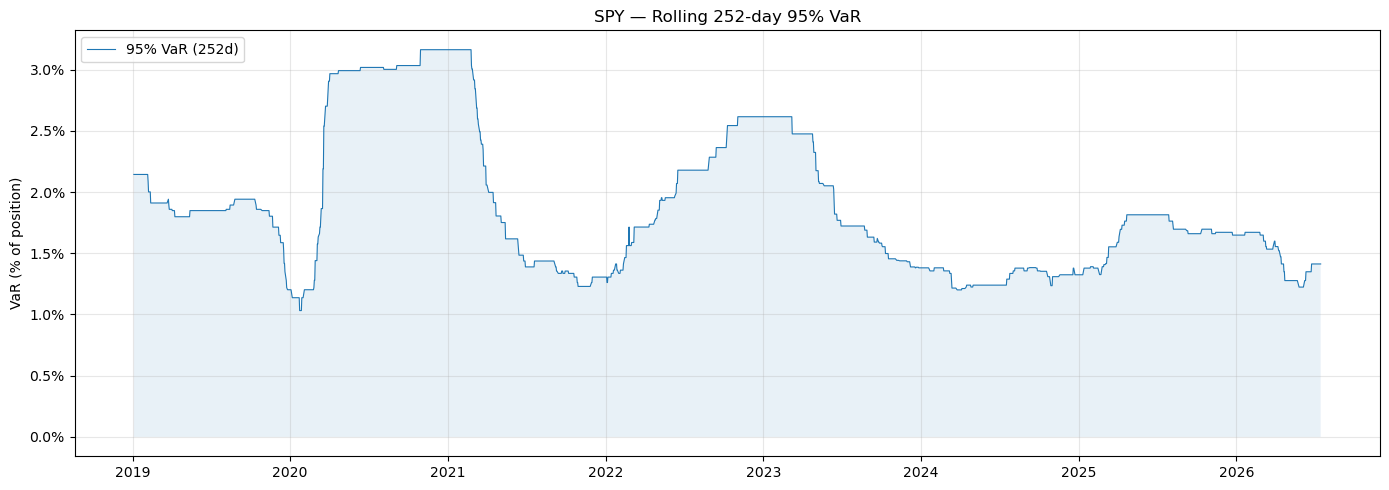

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(result.index, result["VaR"], linewidth=0.8, label=f"{CONFIDENCE:.0%} VaR ({WINDOW}d)")
ax.fill_between(result.index, 0, result["VaR"], alpha=0.1)
ax.set_ylabel("VaR (% of position)")
ax.set_title(f"{TICKER} — Rolling {WINDOW}-day {CONFIDENCE:.0%} VaR")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part B: Breach summary

A breach occurs when the actual loss exceeds the VaR forecast. At 95% confidence, we expect ~5% of days to breach over a large sample.

In [7]:
summary = breach_summary(result, confidence=CONFIDENCE)

excess = summary["breach_rate"] - summary["expected_rate"]
direction = "above" if excess > 0 else "below"

print(f"{'Metric':<25} {'Value':>10}")
print("-" * 36)
print(f"{'Total observations':<25} {summary['total_observations']:>10,}")
print(f"{'Breaches':<25} {summary['breaches']:>10,}")
print(f"{'Breach rate':<25} {summary['breach_rate']:>10.4%}")
print(f"{'Expected rate':<25} {summary['expected_rate']:>10.4%}")
print(f"{'Difference':<25} {abs(excess):>10.4%} {direction} expected")

Metric                         Value
------------------------------------
Total observations             1,891
Breaches                          90
Breach rate                  4.7600%
Expected rate                5.0000%
Difference                   0.2400% below expected


### What this means

If the breach rate is close to the expected rate, the model is **well-calibrated** — it produces roughly the right number of breaches over the full period.

But this is an average. It doesn't tell us *when* the breaches happened. All of them could be concentrated in a single crisis month, and the average would still look fine. That's the subject of Notebook 04.

---

## Part C: Breach timeline

Every red dot is a day where the actual loss was larger than the VaR forecast.

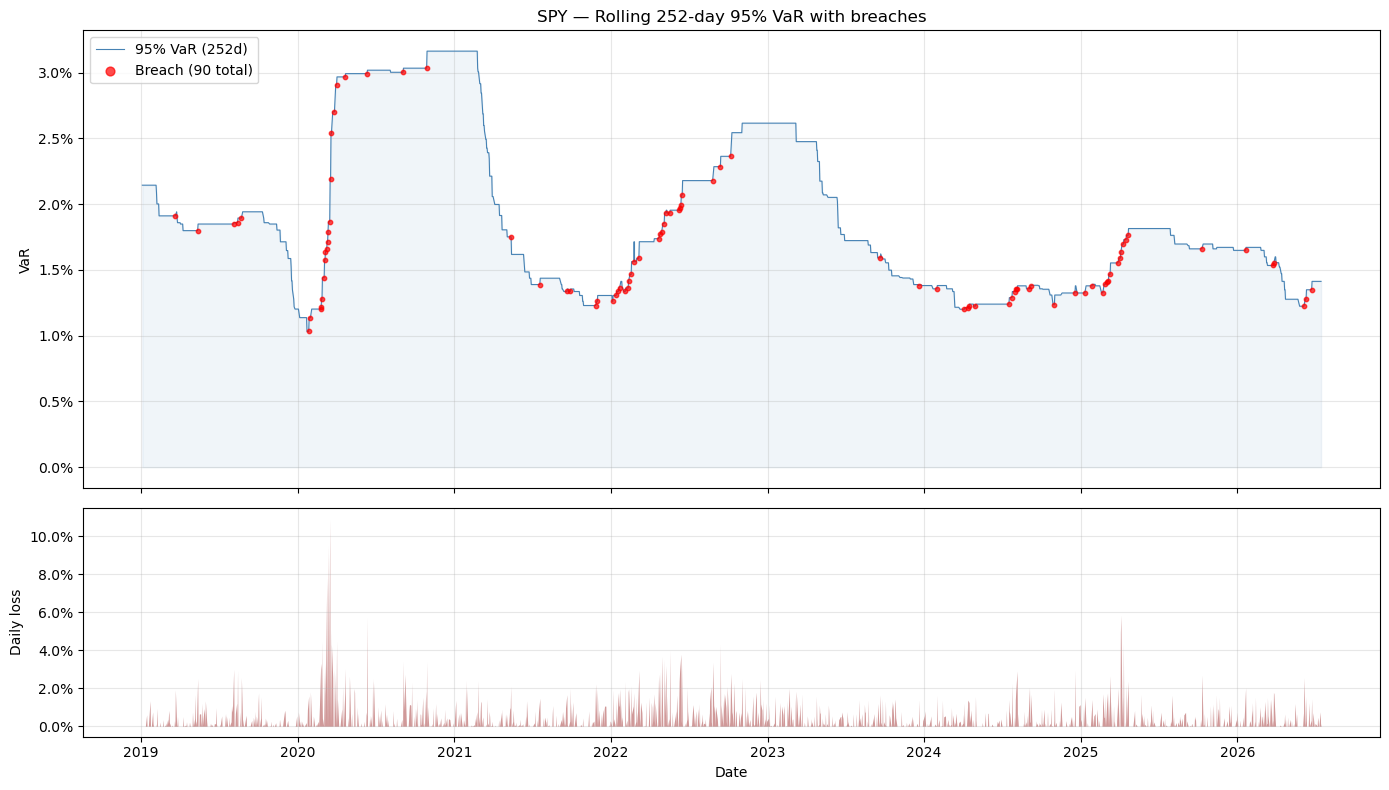

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# Top: VaR line + breaches
ax1.plot(result.index, result["VaR"], linewidth=0.8, color="steelblue", label=f"{CONFIDENCE:.0%} VaR ({WINDOW}d)")
ax1.fill_between(result.index, 0, result["VaR"], alpha=0.08, color="steelblue")

breach_mask = result["Breach"]
ax1.scatter(result.index[breach_mask], result["VaR"][breach_mask],
           color="red", s=10, alpha=0.7, zorder=5, label=f"Breach ({breach_mask.sum()} total)")

ax1.set_ylabel("VaR")
ax1.set_title(f"{TICKER} — Rolling {WINDOW}-day {CONFIDENCE:.0%} VaR with breaches")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax1.legend(loc="upper left", markerscale=2)
ax1.grid(True, alpha=0.3)

# Bottom: realised losses (absolute value of negative returns)
losses = -result["NextReturn"].clip(upper=0)  # only negative returns, as positive values
ax2.fill_between(result.index, 0, losses, alpha=0.4, color="darkred", linewidth=0)
ax2.set_ylabel("Daily loss")
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the chart

- **Top chart:** The blue line is the model's risk estimate. Red dots are days where losses exceeded the estimate. Most red dots should be *below* the blue line — the model is saying "losses shouldn't exceed this," and on breach days, they do.
- **Bottom chart:** The realised losses. Tall bars are bad days. Breaches tend to cluster around the tall bars.

Notice that breaches are not evenly spread — they bunch up during volatile periods. The model is most wrong exactly when you need it most.

---

## Key insight

A well-calibrated VaR model produces roughly the expected breach rate over long periods. But the average hides the timing — breaches cluster during crises. The model is calibrated on average but wrong when it matters.

Next: [03 — Window Comparison](./03_window_comparison.ipynb) — how does the window size change what the model sees?